# Hydrophobins in *Apiospora arundinis*

Class I and class II profile HMMs are built from 21 characterised hydrophobins and used to search
the proteome. Hits are classified by the higher-scoring profile, compared with Pfam, and placed in a
maximum-likelihood phylogeny.

Inputs: `data/hydrophobin_references.fasta`, `data/protein.faa`

In [1]:
import glob, gzip, platform, shutil, subprocess, sys, urllib.request
import importlib.metadata as im
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio import Phylo
from pyfamsa import Aligner, Sequence
from pyhmmer.easel import Alphabet, SequenceFile, TextMSA, TextSequence
from pyhmmer.hmmer import hmmsearch
from pyhmmer.plan7 import Background, Builder, HMMFile

REFERENCES = Path("data/hydrophobin_references.fasta")
PROTEOME = Path("data/protein.faa")
OUT = Path("results")
E_CUTOFF = 1e-3
PREFIX = "AaHFB"

OUT.mkdir(exist_ok=True)
ABC = Alphabet.amino()

print("Python", platform.python_version())
for pkg in ["pyhmmer", "pyfamsa", "biopython", "numpy", "pandas", "matplotlib"]:
    print(f"  {pkg:<11}", im.version(pkg))

Python 3.12.6
  pyhmmer     0.12.3
  pyfamsa     0.7.0
  biopython   1.85
  numpy       2.1.1
  pandas      2.2.2
  matplotlib  3.9.2


## Load data

In [2]:
def read_fasta(path):
    name, seq = None, []
    for line in open(path):
        line = line.strip()
        if line.startswith(">"):
            if name:
                yield name, "".join(seq)
            name, seq = line[1:], []
        elif line:
            seq.append(line)
    if name:
        yield name, "".join(seq)


refs = pd.DataFrame(
    [{"name": h.split()[0], **dict(f.split("=") for f in h.split()[1:]), "sequence": s}
     for h, s in read_fasta(REFERENCES)]
)
proteome = {h.split()[0]: (h.split(" ", 1)[1].rsplit(" [", 1)[0], s)
            for h, s in read_fasta(PROTEOME)}

print(refs["class"].value_counts().to_dict(), "references;", len(proteome), "proteins")

{'II': 11, 'I': 10} references; 15721 proteins


## Build class profiles and search the proteome

In [3]:
aligner = Aligner(guide_tree="upgma")
hmms = {}
for cls, group in refs.groupby("class"):
    aln = aligner.align([Sequence(n.encode(), s.encode())
                         for n, s in zip(group["name"], group["sequence"])])
    msa = TextMSA(name=f"hydrophobin_class{cls}".encode(),
                  sequences=[TextSequence(name=a.id, sequence=a.sequence.decode()) for a in aln])
    hmms[cls], _, _ = Builder(ABC).build_msa(msa.digitize(ABC), Background(ABC))

with open(OUT / "class_profiles.hmm", "wb") as fh:
    for hmm in hmms.values():
        hmm.write(fh)

with SequenceFile(PROTEOME, digital=True, alphabet=ABC) as sf:
    targets = sf.read_block()

scores = {}
for cls, hmm in hmms.items():
    for hits in hmmsearch([hmm], targets, E=1.0):
        for hit in hits:
            scores.setdefault(hit.name.decode() if isinstance(hit.name, bytes) else hit.name,
                              {})[cls] = (hit.score, hit.evalue)

ranked = []
for acc, s in scores.items():
    best = max(s, key=lambda c: s[c][0])
    runner_up = max((s[c][0] for c in s if c != best), default=0.0)
    ranked.append({"protein": acc, "class": best, "evalue": s[best][1],
                   "margin_bits": round(s[best][0] - runner_up, 1)})
ranked = pd.DataFrame(ranked).sort_values("evalue")

hfb = ranked[ranked["evalue"] < E_CUTOFF].sort_values(["class", "evalue"]).reset_index(drop=True)
hfb.insert(0, "name", [f"{PREFIX}{i}" for i in range(1, len(hfb) + 1)])
hfb["length"] = [len(proteome[p][1]) for p in hfb["protein"]]
hfb["annotation"] = [proteome[p][0] for p in hfb["protein"]]

next_best = ranked[ranked["evalue"] >= E_CUTOFF]["evalue"].min()
print(f"{len(hfb)} hydrophobins at E < {E_CUTOFF:g}; next protein E = {next_best:.1e}")
hfb

6 hydrophobins at E < 0.001; next protein E = 4.3e-03


,name,protein,class,evalue,margin_bits,length,annotation
0,AaHFB1,KAK8856621.1,I,3.998675e-18,65.6,145,fungal hydrophobin
1,AaHFB2,KAK8879197.1,I,3.200895e-05,23.9,99,chromo (CHRromatin organization MOdifier) doma...
2,AaHFB3,KAK8879637.1,II,1.288885e-37,127.4,100,fungal hydrophobin
3,AaHFB4,KAK8873671.1,II,3.933362e-34,116.3,102,fungal hydrophobin
4,AaHFB5,KAK8875145.1,II,6.485963e-28,96.3,125,hydrophobin-like protein
5,AaHFB6,KAK8856546.1,II,7.783062e-11,41.6,330,hypothetical protein PGQ11_012458


## Compare with Pfam PF01185 and PF06766

In [4]:
pfam_file = OUT / "pfam_hydrophobin.hmm"
if not pfam_file.exists():
    models = []
    for acc in ["PF01185", "PF06766"]:
        url = f"https://www.ebi.ac.uk/interpro/wwwapi//entry/pfam/{acc}?annotation=hmm"
        models.append(gzip.decompress(urllib.request.urlopen(url, timeout=120).read()).decode())
    pfam_file.write_text("".join(models))

with HMMFile(pfam_file) as hf:
    pfam = {}
    for hits in hmmsearch(list(hf), targets, bit_cutoffs="gathering"):
        for hit in hits:
            name = hit.name.decode() if isinstance(hit.name, bytes) else hit.name
            pfam[name] = hits.query.name.decode() if isinstance(hits.query.name, bytes) else hits.query.name

hfb["pfam"] = [pfam.get(p, "no hit") for p in hfb["protein"]]
print(f"Pfam recovers {(hfb['pfam'] != 'no hit').sum()} of {len(hfb)}; "
      f"{len(set(pfam) - set(hfb['protein']))} additional proteins")
hfb[["name", "protein", "class", "evalue", "pfam"]]

Pfam recovers 5 of 6; 0 additional proteins


,name,protein,class,evalue,pfam
0,AaHFB1,KAK8856621.1,I,3.998675e-18,Hydrophobin
1,AaHFB2,KAK8879197.1,I,3.200895e-05,no hit
2,AaHFB3,KAK8879637.1,II,1.288885e-37,Hydrophobin_2
3,AaHFB4,KAK8873671.1,II,3.933362e-34,Hydrophobin_2
4,AaHFB5,KAK8875145.1,II,6.485963e-28,Hydrophobin_2
5,AaHFB6,KAK8856546.1,II,7.783062e-11,Hydrophobin_2


## Phylogeny of the C1–C8 domain

In [5]:
import re

core = re.compile(r"C.{3,25}CC.{4,50}C.{4,40}C.{3,25}CC.{3,40}C")

def domain(seq):
    starts = [i for i, a in enumerate(seq) if a == "C" and core.match(seq, i)]
    return core.match(seq, starts[-1]).group() if starts else None

taxa = [(r["name"], domain(r["sequence"]), r["class"]) for _, r in refs.iterrows()]
taxa += [(r["name"], domain(proteome[r["protein"]][1]), r["class"]) for _, r in hfb.iterrows()]

aln = aligner.align([Sequence(n.encode(), s.encode()) for n, s, _ in taxa])
names = [a.id.decode() for a in aln]
matrix = np.array([list(a.sequence.decode()) for a in aln])
matrix = matrix[:, (matrix == "-").mean(axis=0) <= 0.5]
(OUT / "domain_alignment.fasta").write_text(
    "".join(f">{n}\n{''.join(row)}\n" for n, row in zip(names, matrix)))

iqtree = (shutil.which("iqtree2") or shutil.which("iqtree")
          or next(iter(glob.glob("tools/iqtree*/bin/iqtree2.exe")
                       + glob.glob("tools/iqtree*/bin/iqtree2")), None))
assert iqtree, "IQ-TREE 2 not found: put it on PATH or in tools/"
subprocess.run([iqtree, "-s", str(OUT / "domain_alignment.fasta"), "-m", "MFP",
                "-B", "1000", "-alrt", "1000", "-T", "1", "--seed", "1",
                "--prefix", str(OUT / "iqtree"), "-redo", "-quiet"], check=True)

model = next(l for l in open(OUT / "iqtree.iqtree") if l.startswith("Best-fit model"))
print(matrix.shape[1], "alignment columns;", model.strip())

61 alignment columns; Best-fit model according to BIC: WAG+I+G4


class I / class II split (SH-aLRT/UFBoot): 100/100


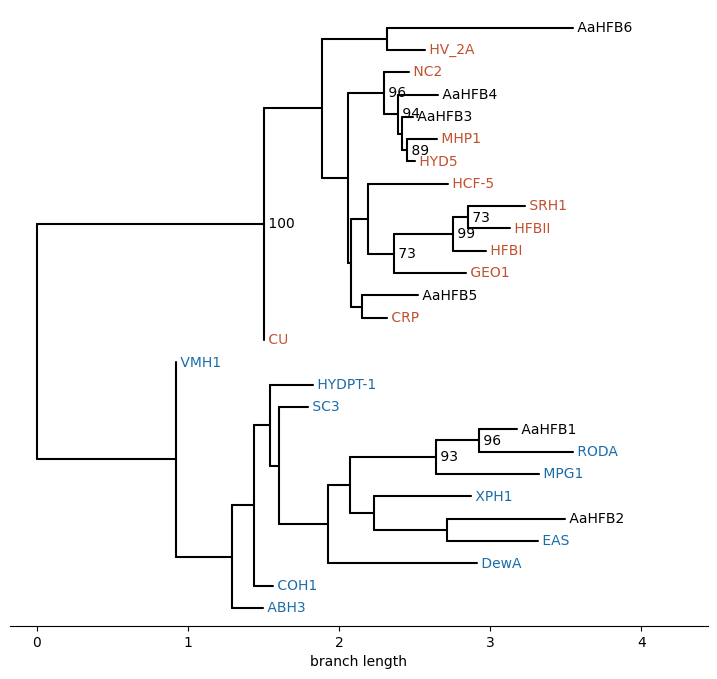

In [6]:
tree = Phylo.read(OUT / "iqtree.treefile", "newick")
class_of = {n: c for n, _, c in taxa}
class_I = frozenset(n for n, c in class_of.items() if c == "I")

for clade in tree.get_nonterminals():
    tips = frozenset(t.name for t in clade.get_terminals())
    if tips in (class_I, frozenset(class_of) - class_I):
        print("class I / class II split (SH-aLRT/UFBoot):", clade.confidence or clade.name)

for clade in tree.get_nonterminals():
    label = clade.confidence if clade.confidence is not None else clade.name
    clade.name, clade.confidence = None, float(str(label).split("/")[-1]) if label else None
tree.root_at_midpoint()

colours = {"I": "#1b6ca8", "II": "#c1502e"}
fig, ax = plt.subplots(figsize=(9, 8))
Phylo.draw(tree, axes=ax, do_show=False, show_confidence=False,
           label_func=lambda c: c.name if c.is_terminal()
           else (f"{c.confidence:.0f}" if c.confidence and c.confidence >= 70 else ""),
           label_colors=lambda n: "black" if n.startswith(PREFIX) else colours.get(class_of.get(n)))
ax.set_yticks([]); ax.set_ylabel("")
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
fig.savefig(OUT / "tree.png", dpi=300, bbox_inches="tight")

## Export

In [7]:
hfb.to_csv(OUT / "hydrophobins.tsv", sep="\t", index=False)
(OUT / "hydrophobins.fasta").write_text(
    "".join(f">{r['name']} {r['protein']} class={r['class']}\n{proteome[r['protein']][1]}\n"
            for _, r in hfb.iterrows()))
hfb.drop(columns="annotation")

,name,protein,class,evalue,margin_bits,length,pfam
0,AaHFB1,KAK8856621.1,I,3.998675e-18,65.6,145,Hydrophobin
1,AaHFB2,KAK8879197.1,I,3.200895e-05,23.9,99,no hit
2,AaHFB3,KAK8879637.1,II,1.288885e-37,127.4,100,Hydrophobin_2
3,AaHFB4,KAK8873671.1,II,3.933362e-34,116.3,102,Hydrophobin_2
4,AaHFB5,KAK8875145.1,II,6.485963e-28,96.3,125,Hydrophobin_2
5,AaHFB6,KAK8856546.1,II,7.783062e-11,41.6,330,Hydrophobin_2
